# 01 · Your first simulation

Run a stock Gainesville maize treatment and use its results to compare grain yield and follow crop growth.

## You will learn

- Identify treatments and their management levels in a FileX.
- Run one treatment and read grain yield, anthesis date and maturity date.
- Plot daily plant growth and compare grain yield with another treatment.

In [1]:
LESSON = "01_first_simulation"

In [2]:
# Connect to DSSAT and prepare a fresh copy of the lesson's data.
import os, shutil, subprocess, sys
from pathlib import Path
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "dssatlab[course]>=0.23,<0.24"], check=True, capture_output=True)
    if Path.cwd().name != LESSON:
        if not Path("dssatlab").exists():
            subprocess.run(["git", "clone", "--depth", "1", "https://github.com/AbdelrahmanAmr3/dssatlab"], check=True)
        os.chdir(Path("dssatlab") / "course" / LESSON)
import dssatlab as dl
if "google.colab" in sys.modules:
    dl.install()
dssat = dl.connect()
HERE = Path.cwd()
RUNS = HERE / "runs"
if RUNS.exists():
    shutil.rmtree(RUNS)
_ = shutil.copytree(HERE / "data", RUNS)

## 1 · Look inside the FileX

A FileX describes fields, cultivars, initial conditions, management and simulation controls for one experiment.
Here the case uses `UFGA8201.WTH` and soil profile `IBMZ910014` in `SOIL.SOL`; the setup cell has copied these inputs into `runs/`.

Select the FileX in `RUNS` so DSSAT uses the fresh copy of the lesson inputs.

In [3]:
# Select the copied FileX.
filex = RUNS / "UFGA8201.MZX"

Show the TREATMENTS section to see the treatment numbers, names and management levels.

In [4]:
# Preview the treatment rows in this stock FileX.
print("\n".join(filex.read_text(encoding="latin-1").splitlines()[10:20]))

*TREATMENTS                        -------------FACTOR LEVELS------------
@N R O C TNAME.................... CU FL SA IC MP MI MF MR MC MT ME MH SM
 1 1 0 0 RAINFED LOW NITROGEN       1  1  0  1  1  1  1  0  0  0  0  0  1
 2 1 0 0 RAINFED HIGH NITROGEN      1  1  0  1  1  1  2  0  0  0  0  0  1
 3 1 0 0 IRRIGATED LOW NITROGEN     1  1  0  1  1  2  1  0  0  0  0  0  1
 4 1 0 0 IRRIGATED HIGH NITROGEN    1  1  0  1  1  2  2  0  0  0  0  0  1
 5 1 0 0 VEG STRESS LOW NITROGEN    1  1  0  1  1  3  1  0  0  0  0  0  1
 6 1 0 0 VEG STRESS HIGH NITROGEN   1  1  0  1  1  3  2  0  0  0  0  0  1

*CULTIVARS


🌱 Crop idea: `N` is the treatment number; `MI` and `MF` select irrigation and fertilizer levels.
Treatments 1 and 2 share irrigation level 1 and use different fertilizer levels; keep the stock treatment names when interpreting their results.

## 2 · Run treatment 1

Run treatment 1, named RAINFED LOW NITROGEN, to produce its simulated season.

In [5]:
# Run the first treatment.
result = dl.run(filex, treatment=1)

Check the DSSAT exit status, where zero means the executable completed successfully.

In [6]:
# Show the DSSAT exit status.
print("DSSAT exit status:", result.returncode)

DSSAT exit status: 0


Show the run directory relative to the lesson folder so you can find its output files.

In [7]:
# Show the relative run directory.
print(result.run_dir.relative_to(HERE).as_posix())

runs/dssat_run_2026-10-06_195558


## 3 · Read the summary

Read the summary to get one row of end-of-season results for this treatment.

In [8]:
# Read the end-of-season summary.
summary = dl.read_summary(result.run_dir)

Display grain yield (`HWAM`, kg/ha), anthesis date (`ADAT`) and maturity date (`MDAT`) together.

In [9]:
# Display the yield and crop development dates.
dl.to_dataframe(summary)[["TRNO", "TNAM", "HWAM", "ADAT", "MDAT"]]

,TRNO,TNAM,HWAM,ADAT,MDAT
0,1,RAINFED LOW NITROGEN,2293,1982-05-13,1982-07-04


🐍 Python idea: `read_summary()` returns rows, and `to_dataframe()` turns them into a table.
The column names in double brackets select what to display; dates appear as calendar dates and missing values are read as `None`.

## 4 · Follow plant growth

Read plant growth to follow the daily simulated crop development.

In [10]:
# Read daily plant growth.
growth = dl.read_plant_growth(result.run_dir)

Preview daily leaf area index (`LAID`, m² leaf/m² ground) and aboveground biomass (`CWAD`, kg/ha).

In [11]:
# Display the first five daily growth rows.
dl.to_dataframe(growth)[["DATE", "LAID", "CWAD"]].head()

,DATE,LAID,CWAD
0,1982-02-26,0.0,0
1,1982-02-27,0.0,0
2,1982-02-28,0.0,0
3,1982-03-01,0.0,0
4,1982-03-02,0.0,0


Enable inline plotting so the growth curves appear inside this notebook.

In [12]:
# Render plots inside the notebook.
%matplotlib inline

Import matplotlib to display and label the growth curves.

In [13]:
# Load matplotlib for the growth plots.
import matplotlib.pyplot as plt

Plot leaf area index (`LAID`) to see how the canopy develops over the season.

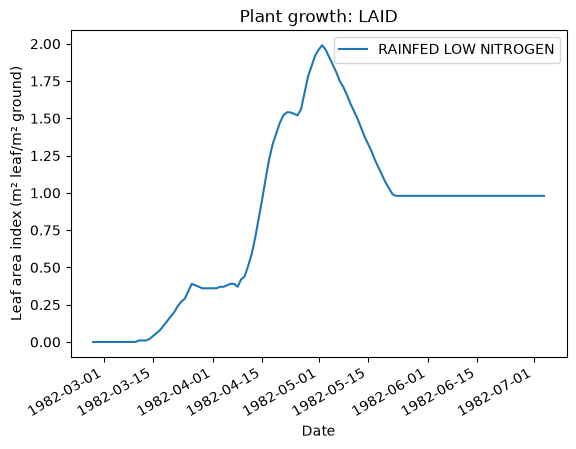

In [14]:
# Plot daily leaf area index.
ax = dl.plot_plant_growth(result.run_dir, variable="LAID")
ax.set_ylabel("Leaf area index (m² leaf/m² ground)")
ax.figure.autofmt_xdate()
plt.show()

Plot aboveground biomass (`CWAD`) to see how much dry matter the crop accumulates.

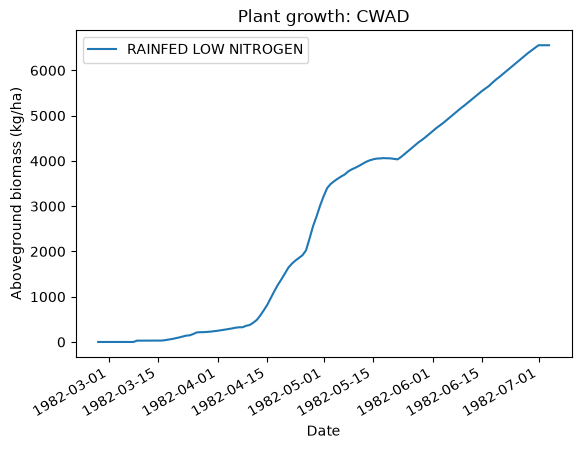

In [15]:
# Plot daily aboveground biomass.
ax = dl.plot_plant_growth(result.run_dir, variable="CWAD")
ax.set_ylabel("Aboveground biomass (kg/ha)")
ax.figure.autofmt_xdate()
plt.show()

## 5 · Find the output files

List the files collected in the run directory so you can find the summary and daily growth output again.

In [16]:
# List collected output files using relative paths.
for path in result.outputs:
    print(path.relative_to(HERE).as_posix())

runs/dssat_run_2026-10-06_195558/DSSAT48.INH
runs/dssat_run_2026-10-06_195558/DSSAT48.INP
runs/dssat_run_2026-10-06_195558/ET.OUT
runs/dssat_run_2026-10-06_195558/Evaluate.OUT
runs/dssat_run_2026-10-06_195558/GHG.OUT
runs/dssat_run_2026-10-06_195558/INFO.OUT
runs/dssat_run_2026-10-06_195558/LUN.LST
runs/dssat_run_2026-10-06_195558/MgmtEvent.OUT
runs/dssat_run_2026-10-06_195558/MgmtOps.OUT
runs/dssat_run_2026-10-06_195558/Mulch.OUT
runs/dssat_run_2026-10-06_195558/N2O.OUT
runs/dssat_run_2026-10-06_195558/OUTPUT.LST
runs/dssat_run_2026-10-06_195558/OVERVIEW.OUT
runs/dssat_run_2026-10-06_195558/PlantGro.OUT
runs/dssat_run_2026-10-06_195558/PlantN.OUT
runs/dssat_run_2026-10-06_195558/RunList.OUT
runs/dssat_run_2026-10-06_195558/SWBalSum.OUT
runs/dssat_run_2026-10-06_195558/SoilNBalSum.OUT
runs/dssat_run_2026-10-06_195558/SoilNi.OUT
runs/dssat_run_2026-10-06_195558/SoilNiBal.OUT
runs/dssat_run_2026-10-06_195558/SoilNoBal.OUT
runs/dssat_run_2026-10-06_195558/SoilTemp.OUT
runs/dssat_run_2026-

## Your turn

Run another treatment and compare its `HWAM` with treatment 1 using the cells below.

Hint: edit `treatment=2` in this one cell; the TREATMENTS preview shows the available numbers.

In [17]:
# Run another treatment; edit the treatment number here.
other_result = dl.run(filex, treatment=2)

Read the new summary to get the other treatment's simulated grain yield.

In [18]:
# Read the other treatment summary.
other_summary = dl.read_summary(other_result.run_dir)

Put both summary rows in one table to compare grain yield in kg/ha.

In [19]:
# Compare grain yields across the two treatments.
dl.to_dataframe(summary + other_summary)[["TRNO", "TNAM", "HWAM"]]

,TRNO,TNAM,HWAM
0,1,RAINFED LOW NITROGEN,2293
1,2,RAINFED HIGH NITROGEN,2293


Subtract treatment 1's yield from the other treatment's yield to measure the difference in kg/ha.

In [20]:
# Show the grain yield difference relative to treatment 1.
print("Other treatment minus treatment 1 (kg/ha):", other_summary[0]["HWAM"] - summary[0]["HWAM"])

Other treatment minus treatment 1 (kg/ha): 0


With the displayed choice of treatment 2, both treatments yield 2,293 kg/ha, a difference of 0 kg/ha.
This comparison describes these two treatments in this simulated season; it alone does not identify which process limited yield.

## Recap

- A FileX treatment points to the field, cultivar and management levels used for its simulation.
- `run()` produces a run directory; `read_summary()` returns yield and development dates.
- `read_plant_growth()` and `plot_plant_growth()` reveal daily canopy and biomass development.

Next: [02 · Planting-date sweep](../02_planting_dates/lesson.ipynb).